# Tutorial 7: Human Breast Cancer Analysis (Xenium)

<p align="left">
  <img src="../../_static/breast_xenium.png" width="150">
</p>

> This tutorial demonstrates how to use SemanticST to identify spatial domains in Xenium data from human breast cancer.


## Import necessary packages

In [ ]:
from sklearn import metrics
import torch
import copy
import os
import random
import numpy as np
from semanticst.loading_batches import PrepareDataloader
from semanticst.loading_batches import Dataloader
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import torch.utils.data as data
from semanticst.main import Config
import warnings
warnings.filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

## Read data and import device

In [2]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"You are using *{device}*")

BASE_PATH = Path('/path_to_your_data/Xenium_breast_cancer.h5ad')
spot_paths= Path(f'{BASE_PATH}')

You are using *cuda:0*


In [3]:
from semanticst.loading_batches import PrepareDataloader


In [4]:
from semanticst.loading_batches import PrepareDataloader
dtype = "Xenium"  
config = Config(spot_paths=spot_paths,device=device,dtype=dtype, use_mini_batch=True)
config_used = copy.copy(config)
loader = PrepareDataloader(config_used)
train_loader, test_loader, num_iter, adata = loader.getloader()
print(adata)

sample_num : 156347
batch_size : 3000
AnnData object with n_obs × n_vars = 156347 × 313
    obs: 'annotation', 'n_counts'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'annotation_colors', 'log1p'
    obsm: 'spatial'


## Plot the annotation


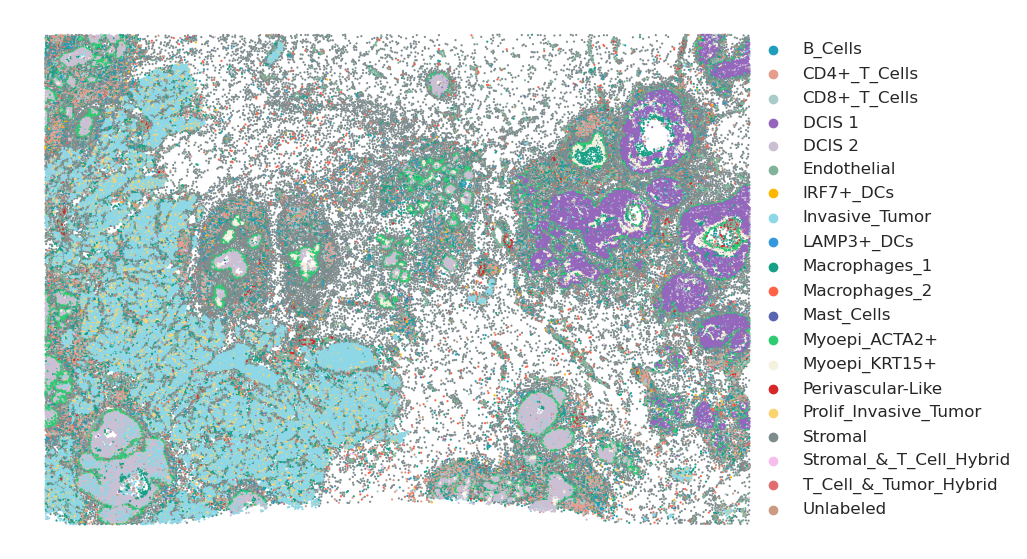

In [252]:
plt.rcParams["figure.figsize"] = (10,7)

#adata.obsm['spatial'][:, 1] = -1 * adata.obsm['spatial'][:, 1]

sc.pl.embedding(adata, basis="spatial", color="annotation", show=False,palette=custom_palette_r, title='',size=10)
plt.gca().invert_yaxis()  # This will invert the y-axis
plt.axis('off')
plt.legend(loc="center right", fontsize=12, markerscale=1,bbox_to_anchor=(1.3, 0.5), borderaxespad=0., frameon=False)
plt.savefig("annotation_breast_cancer_leg", dpi=600, bbox_inches='tight')
plt.show()

## Train the model 
Available: 'Xenium', 'Visium', 'Stereo', 'Slide'.
<br>
It is essential to specify the type of ST data, as different ST technologies require distinct preprocessing steps. Additionally, you have the option to select between mini-batch training for large datasets and full dataset training for smaller ones, ensuring efficient data processing and model performance.</h3>

In [5]:
from semanticst.SemanticST_main import Semantic_batches as Trainer 
model = Trainer(adata, train_loader,test_loader, num_iter,config)  
adata=model.train()  # Train the model



🚀 Welcome to SemanticST! 🚀

📢 Recommendation: If your dataset contains more than 40000 spots or cells, we suggest using **mini-batch training** for efficiency.

✅ Using Mini-Batch Training for better efficiency! 🏋️‍♂️
Begin to train ST data...


Training Progress: 100%|██████████████████████| 53/53 [1:20:36<00:00, 91.26s/it]


Optimization finished for ST data!


Testing Progress: 100%|██████████████████████| 53/53 [00:30<00:00,  1.73batch/s]


## Run the Leiden clustering algorithm 


In [85]:
from sklearn.decomposition import PCA
pca = PCA(n_components=20, random_state=1) 
embedding = pca.fit_transform(adata.obsm['emb_encoder'].copy())
adata.obsm['emb_pca'] = embedding
sc.pp.neighbors(adata, use_rep='emb_pca')
sc.tl.umap(adata)

In [98]:
sc.tl.leiden(adata, random_state=2025, resolution=1.2)

In [232]:
custom_palette_r = [
    '#219ebc',  
    '#e79d8d', 
    '#A9CBCA',  
    '#9467bd', 
    '#cbc0d3', 
    '#81b29a', 
    '#ffb703', 
    '#8ed7e6',  
    '#3498db',  
    '#16a085', 
    '#ff6347', 
    '#5965B0', 
    '#2ecc71',  
     '#f4f1de', 
    '#d62728', 
    '#FAD471', 
    '#7f8c8d',  
    '#F7BEEC', 
    '#E16E6E', 
    '#CC9A81'
]



## Visualize Results


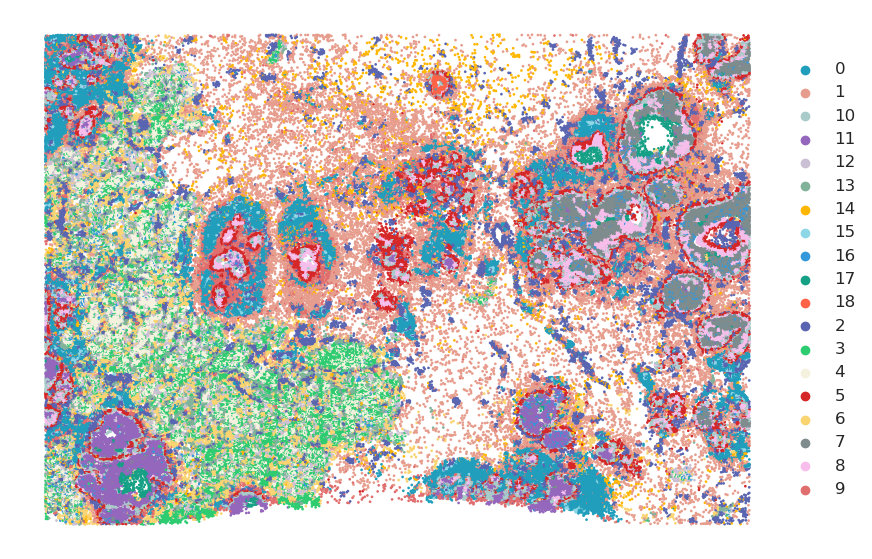

In [261]:
import os
import matplotlib.pyplot as plt
adata.obs['leiden'] = adata.obs['leiden'].astype('category')
plt.rcParams["figure.figsize"] = (10, 7)
s="final_encoder"
d='bcancer_leiden_final_R'
#adata.obsm['spatial'][:, 1] = -1 * adata.obsm['spatial'][:, 1]

plot_color = custom_palette_r

unique_labels = sorted(adata.obs['leiden'].unique())  # Ensure consistent order
label_to_color = {label: plot_color[i] for i, label in enumerate(unique_labels)}
# Plot all clusters together
sc.pl.embedding(adata, basis="spatial", color="leiden", palette=label_to_color, show=False, title="",size=15)
plt.gca().invert_yaxis()  # Invert the y-axis to match the original plot style
plt.axis('off')
plt.legend(loc="center right", fontsize=12, markerscale=1,bbox_to_anchor=(1.1, 0.5), borderaxespad=0., frameon=False)
#plt.savefig(f"SemanticST_{s}_{d}", dpi=600, bbox_inches='tight')
plt.show()



In [ ]:
output_dir = f"Domain_SemanticST_{s}_{d}"
os.makedirs(output_dir, exist_ok=True)
# Plot individual clusters
for label in unique_labels:
    fig, ax = plt.subplots()

    ax.scatter(adata.obsm['spatial'][:, 0], adata.obsm['spatial'][:, 1], 
               c='lightgray', s=5)

    label_indices = adata.obs['leiden'] == label
    ax.scatter(adata.obsm['spatial'][label_indices, 0], 
               adata.obsm['spatial'][label_indices, 1], 
               c=label_to_color[label], s=5)

    ax.set_title("")
    ax.axis('off')

    plt.gca().invert_yaxis()

    safe_label = str(label).replace("/", "_").replace("\\", "_").replace(":", "_")
    output_file = os.path.join(output_dir, f"{safe_label}.png")
    plt.savefig(output_file, bbox_inches='tight', dpi=600)